In [1]:
# Sekcja 1: Importowanie bibliotek

import pandas as pd # tabele danych
import seaborn as sns # źródło danych
import matplotlib.pyplot as plt # wykresy
from scipy import stats # statystyki

from sklearn.model_selection import train_test_split # podzielenei danych na treningowe i testowe
from sklearn.preprocessing import StandardScaler # wyrównanie skali
from sklearn.linear_model import LogisticRegression # regresja logistyczna

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import numpy as np

In [2]:
# Sekcja 2: Wczytanie danych
# Wczytanie zbioru Titanic z biblioteki seaborn
# https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv


titanic = sns.load_dataset("titanic")

print(titanic.head(10))

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

| Kolumna | Znaczenie |
|---|---|
| `survived` | Czy pasażer przeżył: `0` = nie, `1` = tak |
| `pclass` | Klasa biletu: `1` = pierwsza, `2` = druga, `3` = trzecia |
| `sex` | Płeć pasażera: `male` = mężczyzna, `female` = kobieta |
| `age` | Wiek pasażera |
| `sibsp` | Liczba rodzeństwa lub małżonków na statku |
| `parch` | Liczba rodziców lub dzieci na statku |
| `fare` | Cena biletu |
| `embarked` | Port wejścia na statek zapisany skrótem (`S` - Southampton, `C` - Cherbourg, `Q` - Queenstown)|
| `class` | Klasa biletu zapisana słownie: `First`, `Second`, `Third` |
| `who` | Typ osoby: `man`, `woman` lub `child` |
| `adult_male` | Czy pasażer był dorosłym mężczyzną: `True` / `False` |
| `deck` | Pokład/statkowa sekcja, np. `A`, `B`, `C`; często brakuje tej wartości |
| `embark_town` | Miasto/port wejścia na statek |
| `alive` | Czy pasażer przeżył zapisane tekstowo: `yes` / `no` |
| `alone` | Czy pasażer podróżował sam: `True` / `False` |

In [3]:
print("\nBrakujące wartośći w każdej kolumnie: ")
print(titanic.isnull().sum())

print("="*50)

liczba_wierszy_przed = len(titanic)

titanic_clean = titanic.dropna(subset=["age"])

liczba_wierszy_po = len(titanic_clean)

print("\nLiczba wierszy przed czyszczeniem:", liczba_wierszy_przed)
print("Liczba wierszy po czyszczeniu:", liczba_wierszy_po)
print("Usunięto wierszy:", liczba_wierszy_przed - liczba_wierszy_po)

print("="*50)
print(titanic_clean.isnull().sum())


Brakujące wartośći w każdej kolumnie: 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Liczba wierszy przed czyszczeniem: 891
Liczba wierszy po czyszczeniu: 714
Usunięto wierszy: 177
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           530
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
# Sekcja 3 : Katgoryzacja cen biletów (modyfikacja)

def categorize_fare(fare, fare_ranges):
  if fare <= fare_ranges[0]:
    return 0 # niska
  elif fare <= fare_ranges[1]:
    return 1 # średnia
  else:
    return 2 # wysoka


min_fare = titanic_clean["fare"].min()
max_fare = titanic_clean["fare"].max()


fare_step = (max_fare - min_fare) / 3

fare_ranges = [
    min_fare + fare_step, # 0
    min_fare + 2* fare_step # 1
]

print(min_fare)
print(max_fare)

# Wyświetlenie przedziałów cenowych
print("\nPrzedziały cenowe biletów:")
print(f"Niska: {min_fare:.2f} - {fare_ranges[0]:.2f}")
print(f"Średnia: {fare_ranges[0]:.2f} - {fare_ranges[1]:.2f}")
print(f"Wysoka: {fare_ranges[1]:.2f} - {max_fare:.2f}")

0.0
512.3292

Przedziały cenowe biletów:
Niska: 0.00 - 170.78
Średnia: 170.78 - 341.55
Wysoka: 341.55 - 512.33


In [5]:
# Sekcja 4 : Właściwe przygotowanie danych
# * Które kolumny naprawdę mogą pomóc przewidzieć, czy pasażer przeżył?

# Po co wybieramy tylko niektóre cechy?

# Bo nie każda kolumna pomaga modelowi, bo niektóre dane są:
# - przydatne, bo mają związek z przeżyciem,
# - zbędne, bo powtarzają informacje z innych kolumn,
# - problematyczne, bo mają dużo braków,
# - zakazane, bo zawierają odpowiedź.

# [najważnijesze cechy: sex, pcalss, age, fare_category (fare zmienione na nasze kategorie)]

titanic_model = titanic_clean.copy()

titanic_model["sex"] = titanic_model["sex"].map({
    "male" : 1,
    "female": 0
})

titanic_model["fare_category"] = titanic_model["fare"].apply(
    lambda fare: categorize_fare(fare, fare_ranges)
)
print(titanic_model["fare_category"].value_counts())


selected_features = ["sex", "pclass", "age", "fare_category"]
print(titanic_model[selected_features].head(10))

fare_category
0    696
1     15
2      3
Name: count, dtype: int64
    sex  pclass   age  fare_category
0     1       3  22.0              0
1     0       1  38.0              0
2     0       3  26.0              0
3     0       1  35.0              0
4     1       3  35.0              0
6     1       1  54.0              0
7     1       3   2.0              0
8     0       3  27.0              0
9     0       2  14.0              0
10    0       3   4.0              0


In [6]:
# Sekcja 5: Podział danych i skalowanie

x = titanic_model[selected_features]
y = titanic_model["survived"]


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)


scaler = StandardScaler()

# scaler uczy się średniej i odchylenia z danych treningowych, a póznije przekształca
x_train_scaled = scaler.fit_transform(x_train)

# skalujemy tym samym scalerem, który nauczył się na danych treningowych
x_test_scaled = scaler.transform(x_test)


# Sprawdzenie rozmiarów zbiorów
print("Rozmiary zbiorów:")
print(f"X_train: {x_train_scaled.shape}")
print(f"X_test: {x_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Rozmiary zbiorów:
X_train: (571, 4)
X_test: (143, 4)
y_train: (571,)
y_test: (143,)


# **Jak działa skalowanie?**

| pasażer | wiek `age` | cena biletu `fare` |
| ------- | ---------: | -----------------: |
| A       |         10 |                  0 |
| B       |         20 |                100 |
| C       |         30 |                500 |


Cena biletu ma dużo większe liczby niż wiek, więc model mógłby za bardzo zwracać uwagę na fare.


| pasażer | `age` po skalowaniu | `fare` po skalowaniu |
| ------- | ------------------: | -------------------: |
| A       |               -1.22 |                -0.93 |
| B       |                0.00 |                -0.46 |
| C       |                1.22 |                 1.39 |


```
jak dane wypadają względenm swojej kolumny
```

In [7]:
# Sekcja 6: Trenowanie i ocena modelu
#
# Utworzenie modelu regresji logistycznej
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html?utm_source=chatgpt.com

# z = w1 * sex + w2 * pclass + w3 * age + w4 * fare_category + b

# wagi określają: co się dzieje z szansą przeżycia, gdy wartość tej cechy rośnie

# p = 1 / (1 + e^(-z))


model = LogisticRegression(
    random_state = 42,
    C = 0.2
)

model.fit(x_train_scaled, y_train)
print("Liczba wykonanych iteracji:", model.n_iter_)

# Wyświetlenie wag modelu
wagi_modelu = pd.DataFrame({
    "cecha": selected_features,
    "waga": model.coef_[0]
})

print("\nWagi, których nauczył się model:")
print(wagi_modelu)

# Wyświetlenie wyrazu wolnego
print("\nWyraz wolny modelu:")
print(model.intercept_[0])


y_pred = model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("\nWynik modelu:")
print(f"Dokładnosć modelu: {accuracy:.3f}")

print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Liczba wykonanych iteracji: [6]

Wagi, których nauczył się model:
           cecha      waga
0            sex -1.197151
1         pclass -0.968300
2            age -0.556781
3  fare_category -0.003761

Wyraz wolny modelu:
-0.4858558233075974

Wynik modelu:
Dokładnosć modelu: 0.741

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79        87
           1       0.67      0.66      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143




Macierz pomyłek:
                         Model: przeżył (1)  Model: nie przeżył (0)
Prawda: przeżył (1)                      37                      19
Prawda: nie przeżył (0)                  18                      69


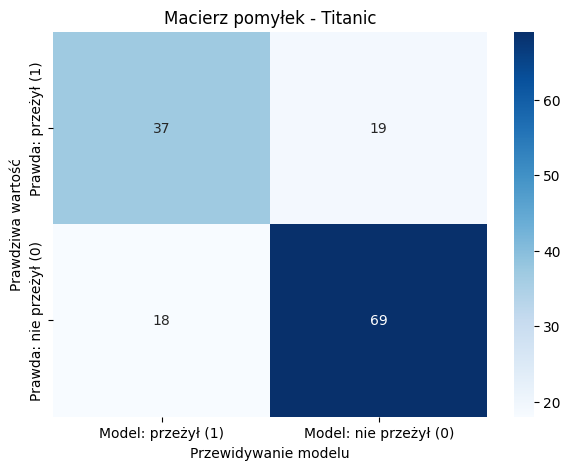

In [8]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=[1,0]
)

# Zamiana macierzy pomyłek na czytelną tabelę
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Prawda: przeżył (1)", "Prawda: nie przeżył (0)"],
    columns=["Model: przeżył (1)", "Model: nie przeżył (0)"]
)

print("\nMacierz pomyłek:")
print(conf_matrix_df)

print("="*70)

# Wizualizacja macierzy pomyłek

plt.figure(figsize=(7, 5))

sns.heatmap(
    conf_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Macierz pomyłek - Titanic")
plt.xlabel("Przewidywanie modelu")
plt.ylabel("Prawdziwa wartość")
plt.show()

In [9]:
# Sekcja 7: Interaktywny symulator

while True:
  print("="* 70)
  print("\=== Prognoza przeżycia pasażera ===")
  print("Wpisz 'koniec', aby zakończyć program.")

  try:
    sex_input = input("\nPodaj płeć (m/k): ").lower()
    if sex_input == "koniec":
      break
    sex = 0 if sex_input == 'k' else 1


    pclass_input = input("Podaj klasę podóży (1/2/3):")
    if pclass_input == "koniec":
      break
    pclass = int(pclass_input)


    age_input = input("Podaj wiek: ")
    if age_input == "koniec":
      break
    age = int(age_input)


    print("\nKategorie cenowe biletów:")
    print(f"0 - Niska:   {min_fare:.2f} - {fare_ranges[0]:.2f}")
    print(f"1 - Średnia: {fare_ranges[0]:.2f} - {fare_ranges[1]:.2f}")
    print(f"2 - Wysoka:  {fare_ranges[1]:.2f} - {max_fare:.2f}")

    fare_category_input = input("Podaj kategorię biletu (0/1/2): ")
    if fare_category_input == "koniec":
      break
    fare_category = int(fare_category_input)


    new_passenger = pd.DataFrame(
        [[sex, pclass, age, fare_category]],
        columns=selected_features
    )

    new_passenger_scaled = scaler.transform(new_passenger)

    prediction = model.predict(new_passenger_scaled)
    probability = model.predict_proba(new_passenger_scaled)

    print("\nWyniki prognozy:")
    print(f"Płeć: {'Kobieta' if sex == 0 else 'Mężczyzna'}")
    print(f"Klasa podróży: {pclass}")
    print(f"Wiek: {age}")
    print(f"Kategoria cenowa: {fare_category}")
    print(f"Przewidywanie przeżycia: {'Tak' if prediction[0] == 1 else 'Nie'}")
    print(f"Prawdopodobieństwo przeżycia: {probability[0][1]:.2%}")

  except ValueError:
    print("\nBłąd: wpisz poprawną liczbę")

  dalej = input("\nCzy chcesz sprawdzić kolejnego pasażera? (t/n): ").lower()

  if dalej != "t":
    break

print("\nKoniec programu")

<>:5: SyntaxWarning: invalid escape sequence '\='
<>:5: SyntaxWarning: invalid escape sequence '\='
/tmp/ipykernel_15662/1175205272.py:5: SyntaxWarning: invalid escape sequence '\='
  print("\=== Prognoza przeżycia pasażera ===")


\=== Prognoza przeżycia pasażera ===
Wpisz 'koniec', aby zakończyć program.


KeyboardInterrupt: Interrupted by user